In [1]:
%pip install kaggle pillow scikit-learn matplotlib seaborn tqdm


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Setup
In this section, we will install and set our paths to our dataset. We first install the libraries. Each library is mentioned with its specified reason:
- `os` - to 
- `matplotlib` - to display the images before processing, after processing

In [3]:
import os
import json
import shutil
from pathlib import Path
from collections import Counter
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

After this, we will set our paths accordingly to point to the train, valid and test folders.

In [ ]:
dataset_path = Path('/Users/tharshensurianbalan/Coding/uni-subjects/machine-learning/assignment/dataset')
training_data_path = dataset_path / 'train'
validation_data_path = dataset_path / 'valid'
testing_data_path = dataset_path / 'test'

# Verify the paths
print(f"Dataset path exists: {dataset_path.exists()}")
print(f"Training path exists: {training_data_path.exists()}")
print(f"Validation path exists: {validation_data_path.exists()}")
print(f"Testing path exists: {testing_data_path.exists()}")

Dataset path exists: True
Training path exists: True
Validation path exists: True
Testing path exists: True


# Data Preparation & Processing Pipeline
After installing and setting up the folder paths, we will need to inspect and understand our dataset. From there, we will need to process our data to see if there's any issues with it such as defected or corrupted images.

## Count number of images
In our given dataset, it is split across 3 different folders. We have our training set, validation set and our test set. Our training set and validation set contains several folders. These folders are our classes, representing our type of plants.

In [12]:
# Count the number of images in each data folder by going through each class sub-folder
def count_images_per_class(data_dir):
    """Count the number of images in each class folder."""
    class_counts = {}
    for class_folder in sorted(os.listdir(data_dir)):
        class_path = os.path.join(data_dir, class_folder)
        if os.path.isdir(class_path):
            num_images = len([f for f in os.listdir(class_path)
                            if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            class_counts[class_folder] = num_images
    return class_counts

In [ ]:
# Count images in each split
# For the test set, we will use the count from check_corrupted_images if it doesn't have class subfolders.
# The test_counts will be 0 if there are no subdirectories.
train_counts = count_images_per_class(training_data_path)
valid_counts = count_images_per_class(validation_data_path)
test_counts = count_images_per_class(testing_data_path)

print(f"Training set: {sum(train_counts.values())} images across {len(train_counts)} classes")
print(f"Validation set: {sum(valid_counts.values())} images across {len(valid_counts)} classes")

# Check if test_counts is empty, if so, use the total valid images from the earlier check
if not test_counts and 'test_valid' in globals():
    print(f"Test set: {len(test_valid)} images (total, no class subfolders found)")
else:
    print(f"Test set: {sum(test_counts.values())} images across {len(test_counts)} classes")


Training set: 6552 images across 102 classes
Validation set: 818 images across 102 classes
Test set: 819 images (total, no class subfolders found)


## Check for corrupted images
It's possible for our dataset to include corrupt or defected images. We need to verify if this is or isn't the case.

In [14]:
def check_corrupted_images(folder_path):
    """
    Scan all images in a folder and check if they can be opened.
    Returns lists of valid and corrupted image paths.
    """
    valid_images = []
    corrupted_images = []

    # Walk through all subfolders (class folders)
    for root, directories, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(root, filename)
                try:
                    # Try to open and verify the image
                    with Image.open(img_path) as img:
                        img.verify()  # This checks if file is corrupted
                    valid_images.append(img_path)
                except Exception as e:
                    corrupted_images.append((img_path, str(e)))

    return valid_images, corrupted_images

In [15]:
# Run on each split
print("Checking TRAIN folder...")
train_valid, train_corrupted = check_corrupted_images(training_data_path)
print(f"  Valid: {len(train_valid)}, Corrupted: {len(train_corrupted)}")

print("Checking VALID folder...")
valid_valid, valid_corrupted = check_corrupted_images(validation_data_path)
print(f"  Valid: {len(valid_valid)}, Corrupted: {len(valid_corrupted)}")

print("Checking TEST folder...")
test_valid, test_corrupted = check_corrupted_images(testing_data_path)
print(f"  Valid: {len(test_valid)}, Corrupted: {len(test_corrupted)}")

# Show corrupted files if any
if train_corrupted:
    print("\n⚠️ Corrupted files in TRAIN:")
    for path, error in train_corrupted:
        print(f"  {path}: {error}")

Checking TRAIN folder...
  Valid: 6552, Corrupted: 0
Checking VALID folder...
  Valid: 818, Corrupted: 0
Checking TEST folder...
  Valid: 819, Corrupted: 0


In [16]:
def check_flipped_images(folder_path):
    """
    Scans images for EXIF orientation tags which indicate the image 
    might be rotated or flipped.
    """
    flipped_count = 0
    total_images = 0
    affected_files = []

    for root, dirs, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                total_images += 1
                img_path = os.path.join(root, filename)
                try:
                    with Image.open(img_path) as img:
                        # EXIF tag 274 is 'Orientation'
                        exif = img._getexif()
                        if exif and 274 in exif:
                            orientation = exif[274]
                            # Orientations 2-8 imply some form of flipping or rotation
                            if orientation > 1:
                                flipped_count += 1
                                affected_files.append(img_path)
                except (AttributeError, KeyError, IndexError):
                    # No EXIF data found, assuming image is standard
                    pass
                except Exception as e:
                    print(f"Error checking {img_path}: {e}")

    print(f"Folder: {folder_path}")
    print(f"  - Total images scanned: {total_images}")
    print(f"  - Flipped/Rotated images detected: {flipped_count}")
    return affected_files

# Run the check on all paths
print("Checking for orientation issues...")
train_flipped = check_flipped_images(training_data_path)
valid_flipped = check_flipped_images(validation_data_path)
test_flipped = check_flipped_images(testing_data_path)

Checking for orientation issues...
Folder: /Users/tharshensurianbalan/Coding/uni-subjects/machine-learning/assignment/dataset/train
  - Total images scanned: 6552
  - Flipped/Rotated images detected: 0
Folder: /Users/tharshensurianbalan/Coding/uni-subjects/machine-learning/assignment/dataset/valid
  - Total images scanned: 818
  - Flipped/Rotated images detected: 0
Folder: /Users/tharshensurianbalan/Coding/uni-subjects/machine-learning/assignment/dataset/test
  - Total images scanned: 819
  - Flipped/Rotated images detected: 0


## Get image statistics

In [17]:
def get_image_stats(folder_path):
    """
    Collect dimension and file size statistics for all images.
    """
    dimensions = []
    file_sizes = []

    for root, dirs, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(root, filename)
                try:
                    with Image.open(img_path) as img:
                        dimensions.append(img.size)  # (width, height)
                    file_sizes.append(os.path.getsize(img_path))
                except:
                    pass

    return dimensions, file_sizes

In [18]:
# Get stats for training set
dimensions, file_sizes = get_image_stats(training_data_path)

widths = [d[0] for d in dimensions]
heights = [d[1] for d in dimensions]

print("=" * 50)
print("IMAGE DIMENSION STATISTICS (Training Set)")
print("=" * 50)
print(f"Total images: {len(dimensions)}")
print(f"\nWidth:")
print(f"  Min: {min(widths)} px")
print(f"  Max: {max(widths)} px")
print(f"  Mean: {np.mean(widths):.1f} px")
print(f"\nHeight:")
print(f"  Min: {min(heights)} px")
print(f"  Max: {max(heights)} px")
print(f"  Mean: {np.mean(heights):.1f} px")
print(f"\nFile size:")
print(f"  Min: {min(file_sizes)/1024:.1f} KB")
print(f"  Max: {max(file_sizes)/1024:.1f} KB")
print(f"  Mean: {np.mean(file_sizes)/1024:.1f} KB")

IMAGE DIMENSION STATISTICS (Training Set)
Total images: 6552

Width:
  Min: 500 px
  Max: 1024 px
  Mean: 630.4 px

Height:
  Min: 500 px
  Max: 1168 px
  Mean: 534.3 px

File size:
  Min: 11.7 KB
  Max: 121.7 KB
  Mean: 41.3 KB


## Identify the distribution
We need to understand if our dataset is enough for each class. We expect the classes to be within a close range of numbers

In [19]:
def get_class_distribution(folder_path):
    """
    Count how many images are in each class folder.
    """
    class_counts = {}

    # Each subfolder is a class (named 1, 2, 3, ... 102)
    for class_folder in sorted(Path(folder_path).iterdir()):
        if class_folder.is_dir():
            class_name = class_folder.name
            # Count images in this class
            num_images = len(list(class_folder.glob("*.jpg"))) + \
                        len(list(class_folder.glob("*.png")))
            class_counts[class_name] = num_images

    return class_counts

In [20]:
# Get distribution
train_distribution = get_class_distribution(training_data_path)

# Convert to sorted list for analysis
class_names = sorted(train_distribution.keys(), key=lambda x: int(x))
counts = [train_distribution[c] for c in class_names]

print("=" * 50)
print("CLASS DISTRIBUTION (Training Set)")
print("=" * 50)
print(f"Number of classes: {len(train_distribution)}")
print(f"Total images: {sum(counts)}")
print(f"\nImages per class:")
print(f"  Min: {min(counts)} (Class {class_names[counts.index(min(counts))]})")
print(f"  Max: {max(counts)} (Class {class_names[counts.index(max(counts))]})")
print(f"  Mean: {np.mean(counts):.1f}")
print(f"  Std Dev: {np.std(counts):.1f}")

# Find underrepresented classes (less than mean - 1 std)
threshold = np.mean(counts) - np.std(counts)
underrepresented = [(c, train_distribution[c]) for c in class_names
                    if train_distribution[c] < threshold]

if underrepresented:
    print(f"\n⚠️ Underrepresented classes (< {threshold:.0f} images):")
    for cls, count in sorted(underrepresented, key=lambda x: x[1])[:10]:
        print(f"  Class {cls}: {count} images")

CLASS DISTRIBUTION (Training Set)
Number of classes: 102
Total images: 6552

Images per class:
  Min: 27 (Class 1)
  Max: 206 (Class 51)
  Mean: 64.2
  Std Dev: 35.2

⚠️ Underrepresented classes (< 29 images):
  Class 1: 27 images
  Class 34: 28 images


## Standardise image colour coding and normalise pixel values

In [ ]:
def preprocess_image(img_path, target_size=(128, 128)):
    """
    Load and preprocess a single image for ML.

    Steps:
    1. Load image
    2. Convert to RGB (handles grayscale/RGBA)
    3. Resize to consistent size
    4. Normalize pixel values to 0-1

    Returns: numpy array of shape (height, width, 3)
    """
    img = Image.open(img_path)
    

    # Convert to RGB if needed (some images might be grayscale or RGBA)
    if img.mode != 'RGB':
        img = img.convert('RGB')

    # Resize to target size
    img = img.resize(target_size, Image.LANCZOS)

    # Convert to numpy array and normalize
    img_array = np.array(img, dtype=np.float32) / 255.0

    return img_array

In [24]:
IMG_SIZE = (64, 64)

def load_dataset(folder_path):
    X, y = [], []

    # Sort numerically, not alphabetically
    class_names = sorted(os.listdir(folder_path), key=lambda x: int(x))

    for label, class_name in enumerate(class_names):
        class_path = os.path.join(folder_path, class_name)

        if not os.path.isdir(class_path):
            continue

        for img_name in os.listdir(class_path):
            if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            img_path = os.path.join(class_path, img_name)
            try:
                img = Image.open(img_path).convert("RGB")
                img = img.resize(IMG_SIZE)
                img_array = np.array(img) / 255.0
                X.append(img_array.flatten())
                y.append(label)
            except Exception as e:
                print(f"Skipped {img_path}: {e}")

    return np.array(X), np.array(y), class_names

In [26]:
# Load all datasets
print("Loading training data...")
X_train, y_train, class_names = load_dataset(training_data_path)
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")

print("Loading validation data...")
X_valid, y_valid, _ = load_dataset(validation_data_path)
print(f"  X_valid: {X_valid.shape}, y_valid: {y_valid.shape}")

print("Loading test data...")
# The load_dataset function expects class subfolders, but TEST_PATH has direct images.
# We will manually load X_test and create a placeholder y_test.
X_test = []
# 'test_valid' was populated by check_corrupted_images and contains paths to all valid test images.
for img_path in test_valid:
    try:
        img = Image.open(img_path).convert("RGB")
        img = img.resize(IMG_SIZE)
        img_array = np.array(img) / 255.0
        X_test.append(img_array.flatten())
    except Exception as e:
        print(f"Skipped {img_path}: {e}")
X_test = np.array(X_test)
# Create a placeholder for y_test. Actual labels would typically be loaded from a separate file.
y_test = np.zeros(len(X_test), dtype=int) # Placeholder labels (e.g., all zeros)
print(f"  X_test: {X_test.shape}, y_test: {y_test.shape}")

print(f"\nNumber of classes: {len(class_names)}")

Loading training data...
  X_train: (6552, 12288), y_train: (6552,)
Loading validation data...
  X_valid: (818, 12288), y_valid: (818,)
Loading test data...
  X_test: (819, 12288), y_test: (819,)

Number of classes: 102


APPLYING SINGULAR VALUE DECOMPOSITION (SVD)

Original feature dimension: 12288
Number of components to keep: 1000
Variance explained: 0.9521 (95.21%)

Shape after SVD compression:
  X_train: (6552, 12288) → (6552, 1000)
  X_valid: (818, 12288) → (818, 1000)
  X_test: (819, 12288) → (819, 1000)

Compression ratio: 12.29x


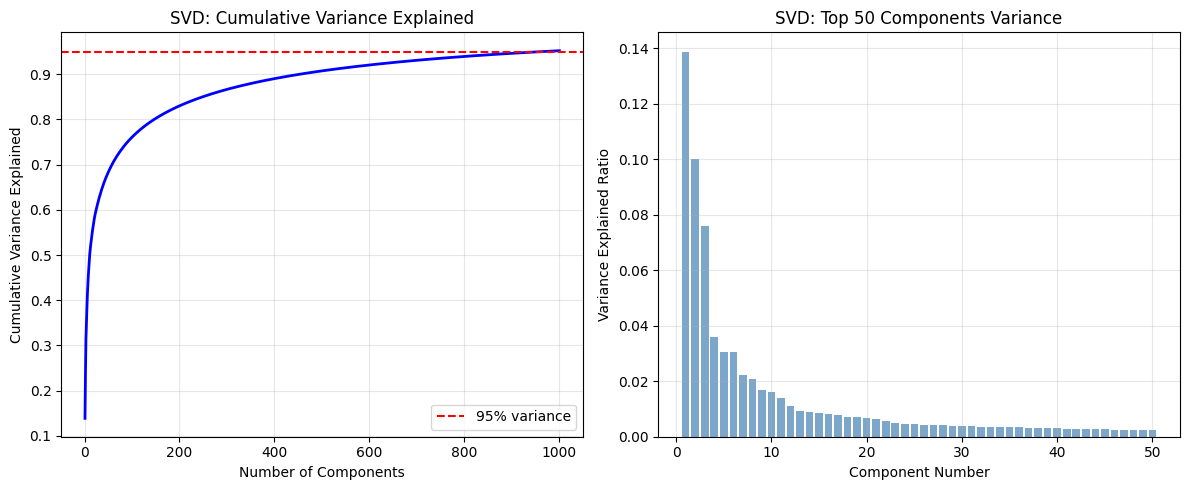


✓ SVD compression completed successfully
✓ Reduced from 12288 to 1000 features


In [42]:
from sklearn.decomposition import TruncatedSVD

# Apply SVD for dimensionality reduction
print("=" * 50)
print("APPLYING SINGULAR VALUE DECOMPOSITION (SVD)")
print("=" * 50)

# Current feature dimension
original_features = X_train.shape[1]
print(f"\nOriginal feature dimension: {original_features}")

# Determine number of components to keep (e.g., 95% of variance)
# We'll use a reasonable number based on the feature space
n_components = min(1000, original_features - 1)  # Keep 300 components or max available

print(f"Number of components to keep: {n_components}")

# Apply SVD to training data
svd = TruncatedSVD(n_components=n_components, random_state=42)
X_train_svd = svd.fit_transform(X_train)

# Apply the same transformation to validation and test data
X_valid_svd = svd.transform(X_valid)
X_test_svd = svd.transform(X_test)

# Calculate variance explained
variance_explained = svd.explained_variance_ratio_.sum()
print(f"Variance explained: {variance_explained:.4f} ({variance_explained*100:.2f}%)")

print(f"\nShape after SVD compression:")
print(f"  X_train: {X_train.shape} → {X_train_svd.shape}")
print(f"  X_valid: {X_valid.shape} → {X_valid_svd.shape}")
print(f"  X_test: {X_test.shape} → {X_test_svd.shape}")

# Calculate compression ratio
compression_ratio = original_features / n_components
print(f"\nCompression ratio: {compression_ratio:.2f}x")

# Plot explained variance
plt.figure(figsize=(12, 5))

# Plot 1: Cumulative variance explained
cumsum_var = np.cumsum(svd.explained_variance_ratio_)
plt.subplot(1, 2, 1)
plt.plot(range(1, len(cumsum_var) + 1), cumsum_var, 'b-', linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('SVD: Cumulative Variance Explained')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Individual variance per component
plt.subplot(1, 2, 2)
plt.bar(range(1, min(51, len(svd.explained_variance_ratio_) + 1)), 
        svd.explained_variance_ratio_[:50], color='steelblue', alpha=0.7)
plt.xlabel('Component Number')
plt.ylabel('Variance Explained Ratio')
plt.title('SVD: Top 50 Components Variance')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ SVD compression completed successfully")
print("✓ Reduced from", original_features, "to", n_components, "features")

In [43]:
# Verification checks after SVD compression
print("=" * 50)
print("SVD COMPRESSION VERIFICATION")
print("=" * 50)

# 1. Check shape reduction
print("\n✓ SHAPE REDUCTION:")
print(f"  Original: {X_train.shape[1]} features")
print(f"  Compressed: {X_train_svd.shape[1]} features")
print(f"  Reduction: {(1 - X_train_svd.shape[1]/X_train.shape[1])*100:.1f}%")

# 2. Check variance preservation
print(f"\n✓ VARIANCE PRESERVED:")
print(f"  Variance explained: {variance_explained*100:.2f}%")
if variance_explained > 0.95:
    print(f"  ✓ GOOD: >95% variance retained")
else:
    print(f"  ⚠ WARNING: <95% variance retained")

# 3. Check data ranges are reasonable
print(f"\n✓ DATA RANGES (should be normalized):")
print(f"  X_train_svd min: {X_train_svd.min():.4f}")
print(f"  X_train_svd max: {X_train_svd.max():.4f}")
print(f"  X_train_svd mean: {X_train_svd.mean():.4f}")
print(f"  X_train_svd std: {X_train_svd.std():.4f}")

# 4. Check no NaN or Inf values
print(f"\n✓ DATA INTEGRITY:")
print(f"  NaN values: {np.isnan(X_train_svd).sum()}")
print(f"  Inf values: {np.isinf(X_train_svd).sum()}")
if np.isnan(X_train_svd).sum() == 0 and np.isinf(X_train_svd).sum() == 0:
    print(f"  ✓ GOOD: No NaN or Inf values")

# 5. Check all datasets were transformed
print(f"\n✓ ALL DATASETS TRANSFORMED:")
print(f"  Train: {X_train_svd.shape}")
print(f"  Valid: {X_valid_svd.shape}")
print(f"  Test: {X_test_svd.shape}")

# 6. Check labels unchanged
print(f"\n✓ LABELS PRESERVED:")
print(f"  y_train shape: {y_train.shape}")
print(f"  y_valid shape: {y_valid.shape}")
print(f"  y_test shape: {y_test.shape}")

# 7. Memory savings
original_size = X_train.nbytes / (1024**2)  # MB
compressed_size = X_train_svd.nbytes / (1024**2)  # MB
print(f"\n✓ MEMORY SAVINGS:")
print(f"  Original size: {original_size:.2f} MB")
print(f"  Compressed size: {compressed_size:.2f} MB")
print(f"  Memory saved: {(1 - compressed_size/original_size)*100:.1f}%")

print("\n" + "=" * 50)
if variance_explained > 0.95 and np.isnan(X_train_svd).sum() == 0:
    print("✓✓✓ SVD COMPRESSION SUCCESSFUL ✓✓✓")
else:
    print("⚠ Review results above for issues")
print("=" * 50)

SVD COMPRESSION VERIFICATION

✓ SHAPE REDUCTION:
  Original: 12288 features
  Compressed: 1000 features
  Reduction: 91.9%

✓ VARIANCE PRESERVED:
  Variance explained: 95.21%
  ✓ GOOD: >95% variance retained

✓ DATA RANGES (should be normalized):
  X_train_svd min: -42.3373
  X_train_svd max: 89.4519
  X_train_svd mean: 0.0426
  X_train_svd std: 1.5868

✓ DATA INTEGRITY:
  NaN values: 0
  Inf values: 0
  ✓ GOOD: No NaN or Inf values

✓ ALL DATASETS TRANSFORMED:
  Train: (6552, 1000)
  Valid: (818, 1000)
  Test: (819, 1000)

✓ LABELS PRESERVED:
  y_train shape: (6552,)
  y_valid shape: (818,)
  y_test shape: (819,)

✓ MEMORY SAVINGS:
  Original size: 614.25 MB
  Compressed size: 49.99 MB
  Memory saved: 91.9%

✓✓✓ SVD COMPRESSION SUCCESSFUL ✓✓✓


# Load the processed dataset

In [33]:
# After loading the dataset
print("=" * 50)
print("DATA LOADING SANITY CHECK")
print("=" * 50)

print(f"\nShapes:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  X_valid: {X_valid.shape}")
print(f"  y_valid: {y_valid.shape}")

print(f"\nLabel range:")
print(f"  Min label: {y_train.min()}")
print(f"  Max label: {y_train.max()}")
print(f"  Unique labels: {len(np.unique(y_train))}")

print(f"\nPixel value range (should be 0-1):")
print(f"  Min: {X_train.min():.4f}")
print(f"  Max: {X_train.max():.4f}")

print(f"\nClass distribution (first 10):")
unique, counts = np.unique(y_train, return_counts=True)
for label, count in list(zip(unique, counts))[:10]:
    print(f"  Class {label}: {count} images")

DATA LOADING SANITY CHECK

Shapes:
  X_train: (6552, 12288)
  y_train: (6552,)
  X_valid: (818, 12288)
  y_valid: (818,)

Label range:
  Min label: 0
  Max label: 101
  Unique labels: 102

Pixel value range (should be 0-1):
  Min: 0.0000
  Max: 1.0000

Class distribution (first 10):
  Class 0: 27 images
  Class 1: 49 images
  Class 2: 36 images
  Class 3: 44 images
  Class 4: 54 images
  Class 5: 35 images
  Class 6: 33 images
  Class 7: 70 images
  Class 8: 41 images
  Class 9: 38 images


In [45]:
# Find the point where each additional component adds minimal value
cumsum_var = np.cumsum(svd.explained_variance_ratio_)

# Show variance at key thresholds
thresholds = [0.85, 0.90, 0.95]
for threshold in thresholds:
    n_components_needed = np.argmax(cumsum_var >= threshold) + 1
    actual_variance = cumsum_var[n_components_needed - 1]
    print(f"{threshold*100:.0f}% variance: {n_components_needed} components ({actual_variance*100:.2f}% actual)")

85% variance: 249 components (85.02% actual)
90% variance: 453 components (90.01% actual)
95% variance: 961 components (95.00% actual)


NameError: name 'X_train' is not defined

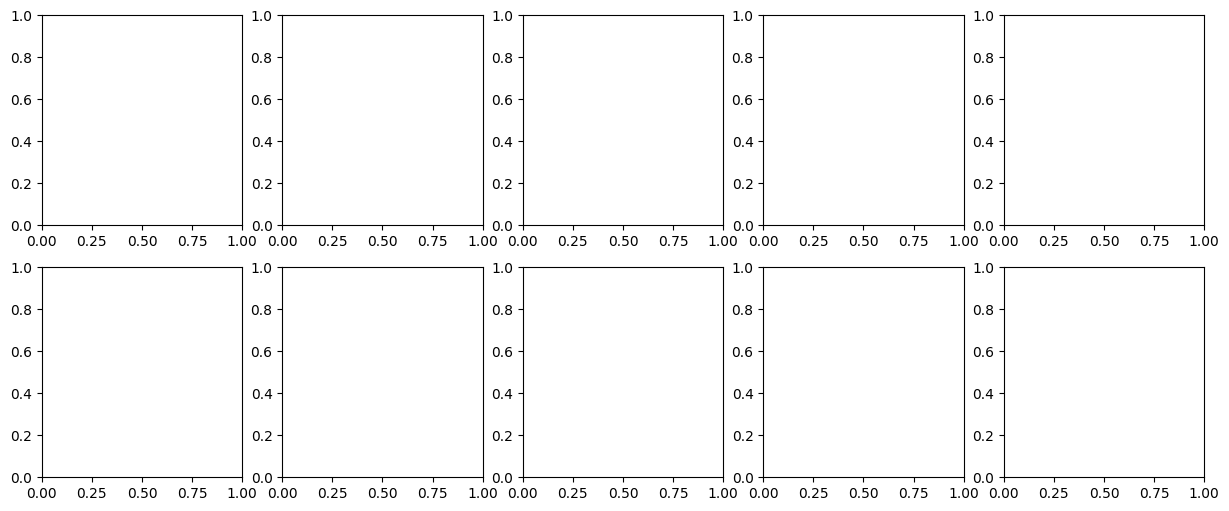

In [21]:
# Display processed images to verify preprocessing
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

# Display 10 random images from training set
np.random.seed(21)
random_indices = np.random.choice(len(X_train), 10, replace=False)

for idx, ax in enumerate(axes):
    img_idx = random_indices[idx]
    # Reshape flattened image back to original dimensions
    img = X_train[img_idx].reshape(IMG_SIZE[0], IMG_SIZE[1], 3)
    ax.imshow(img)
    ax.set_title(f"Class {y_train[img_idx]}")
    ax.axis('off')

plt.suptitle(f"Sample Processed Images (Size: {IMG_SIZE})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ All images successfully resized to", IMG_SIZE)
print("✓ All images converted to RGB (3 channels)")
print("✓ Pixel values normalized to [0, 1]")